<a href="https://colab.research.google.com/github/EtherPNU/62720622/blob/main/0529.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import pandas as pd

# 1. 데이터 파일 열기
df = pd.read_csv('Iris.csv')

In [ ]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
# 2. 데이터 크기 구경하기 (행, 열)
print(df.shape)  # (150, 6) 출력

(150, 6)


In [ ]:
# 3. 열 이름 확인하기
print(df.columns)

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')


In [ ]:
# 4. 기본 정보 및 결측치(null) 확인
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [ ]:
# 5. 간단한 계산 (평균, 최댓값)
print("꽃받침 길이 평균:", df['SepalLengthCm'].mean())
print("꽃잎 너비 최댓값:", df['PetalWidthCm'].max())

꽃받침 길이 평균: 5.843333333333334
꽃잎 너비 최댓값: 2.5


In [ ]:
# 6. 종류별 개수 세기
print(df['Species'].value_counts())#3종류씩 50개체

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [ ]:
#7 특정 조건의 데이터 찾기
cond_petal_len = df[df["PetalLengthCm"] > 2.0]
cond_sepal_width = df[df["SepalWidthCm"] > 3.5]

print(f"꽃잎 길이가 2.0보다 큰 데이터 개수: {len(cond_petal_len)}개")
print(f"꽃받침 너비가 3.5보다 큰 데이터 개수: {len(cond_sepal_width)}개")

꽃잎 길이가 2.0보다 큰 데이터 개수: 100개
꽃받침 너비가 3.5보다 큰 데이터 개수: 18개


In [ ]:
# 문제 8: 특정 붓꽃 종류만 보기

versicolor_mean_petal_len = df[df["Species"] == "Iris-versicolor"][
    "PetalLengthCm"
].mean()
virginica_max_sepal_width = df[df["Species"] == "Iris-virginica"][
    "SepalWidthCm"
].max()

print(
    f"문제 8-1) 'Iris-versicolor'의 평균 꽃잎 길이: {versicolor_mean_petal_len:.2f} cm"
)
print(
    f"문제 8-2) 'Iris-virginica'의 최대 꽃받침 너비: {virginica_max_sepal_width:.2f} cm"
)
print("-" * 50)

문제 8-1) 'Iris-versicolor'의 평균 꽃잎 길이: 4.26 cm
문제 8-2) 'Iris-virginica'의 최대 꽃받침 너비: 3.80 cm
--------------------------------------------------


In [ ]:
# 문제 12: 종류별 평균 비교하기 (표 생성)
summary_table = df.groupby("Species").mean().drop(columns="Id")
print("문제 12) 붓꽃 종류별 특징들의 평균값 표:")
display(summary_table)

문제 12) 붓꽃 종류별 특징들의 평균값 표:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
Species,,,,
Iris-setosa,5.006,3.418,1.464,0.244
Iris-versicolor,5.936,2.770,4.260,1.326
Iris-virginica,6.588,2.974,5.552,2.026


In [ ]:
#문제 15: 새로운 값(면적) 계산 결과
# 꽃받침 면적 = 길이 * 너비
df["SepalArea"] = df["SepalLengthCm"] * df["SepalWidthCm"]
# 꽃잎 면적 = 길이 * 너비
df["PetalArea"] = df["PetalLengthCm"] * df["PetalWidthCm"]
# 품종(Species)별로 그룹화하여 면적의 평균 구하기
area_summary = df.groupby("Species")[["SepalArea", "PetalArea"]].mean()
print(area_summary)
# 가장 큰 종류 찾기 (idxmax() 사용)
max_sepal_species = area_summary["SepalArea"].idxmax()
max_petal_species = area_summary["PetalArea"].idxmax()

print(
    f"꽃받침 면적(Sepal Area)이 가장 큰 종류: {max_sepal_species} (평균 {area_summary.loc[max_sepal_species, 'SepalArea']:.2f} cm²)"
)
print(
    f"꽃잎 면적(Petal Area)이 가장 큰 종류: {max_petal_species} (평균 {area_summary.loc[max_petal_species, 'PetalArea']:.2f} cm²)"
)

                 SepalArea  PetalArea
Species                              
Iris-setosa        17.2088     0.3628
Iris-versicolor    16.5262     5.7204
Iris-virginica     19.6846    11.2962
꽃받침 면적(Sepal Area)이 가장 큰 종류: Iris-virginica (평균 19.68 cm²)
꽃잎 면적(Petal Area)이 가장 큰 종류: Iris-virginica (평균 11.30 cm²)


In [ ]:

top_10_df = df.sort_values(by="PetalArea", ascending=False).head(10)

print("=== 꽃잎 면적 기준 Top 10 데이터 목록 ===")
display(top_10_df[["Id", "PetalLengthCm", "PetalWidthCm", "PetalArea", "Species"]])
species_counts = top_10_df["Species"].value_counts()
display(species_counts)
min_species = species_counts.index[0]
min_count = species_counts.iloc[0]
#가장 적게 포함된 종류는 virginica라는 종이 top 10에 10개 전부 포함되었기에 virginica종 외에 2개

=== 꽃잎 면적 기준 Top 10 데이터 목록 ===


,Id,PetalLengthCm,PetalWidthCm,PetalArea,Species
118,119,6.9,2.3,15.87,Iris-virginica
109,110,6.1,2.5,15.25,Iris-virginica
100,101,6.0,2.5,15.00,Iris-virginica
117,118,6.7,2.2,14.74,Iris-virginica
144,145,5.7,2.5,14.25,Iris-virginica
135,136,6.1,2.3,14.03,Iris-virginica
105,106,6.6,2.1,13.86,Iris-virginica
143,144,5.9,2.3,13.57,Iris-virginica
140,141,5.6,2.4,13.44,Iris-virginica
136,137,5.6,2.4,13.44,Iris-virginica


,count
Species,
Iris-virginica,10


In [ ]:
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv
font10 = fm.FontProperties(
    fname="/usr/share/fonts/truetype/nanum/NanumGothic.ttf", size=10
)

df = pd.read_csv("Iris.csv")


rename_dict = {
    "SepalLengthCm": "꽃받침 길이",
    "SepalWidthCm": "꽃받침 너비",
    "PetalLengthCm": "꽃잎 길이",
    "PetalWidthCm": "꽃잎 너비",
}
df = df.rename(columns=rename_dict)
summary_table = df.groupby("Species").mean().drop(columns="Id")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

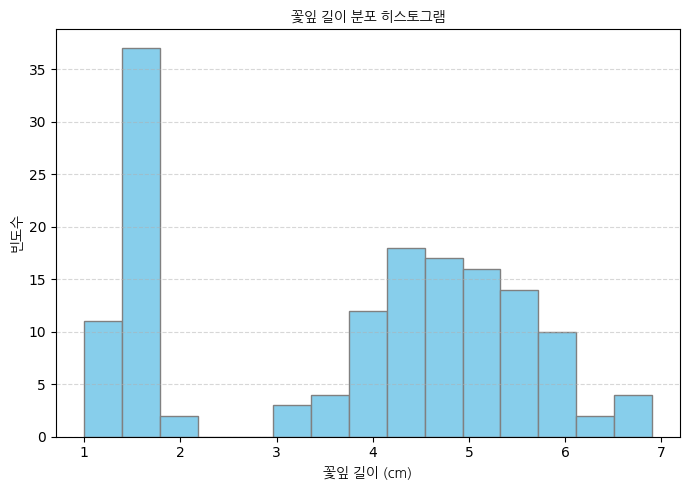

In [ ]:
#문제 9: 꽃잎 길이 히스토그램 그리가
plt.figure(figsize=(7, 5))

plt.hist(df["꽃잎 길이"], bins=15, color="skyblue", edgecolor="gray")
plt.title("꽃잎 길이 분포 히스토그램", fontproperties=font10)
plt.xlabel("꽃잎 길이 (cm)", fontproperties=font10)
plt.ylabel("빈도수", fontproperties=font10)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

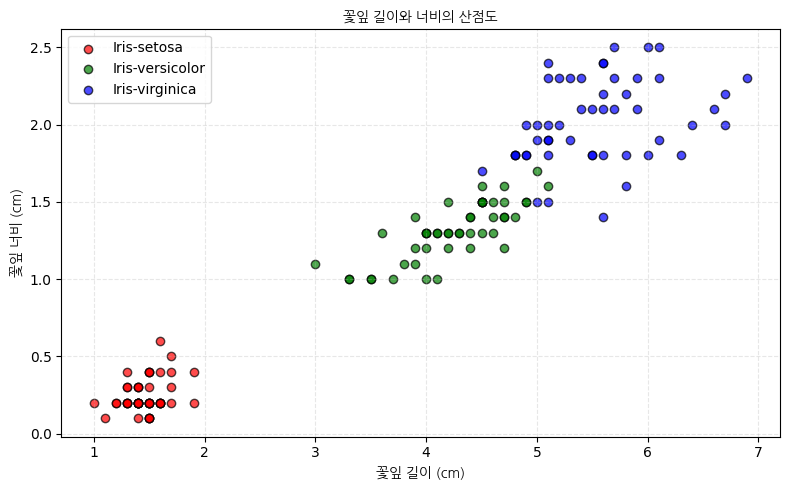

In [ ]:
#문제 10: 산점도 그리기

plt.figure(figsize=(8, 5))
species_list = df["Species"].unique()
colors = ["red", "green", "blue"]

for idx, species in enumerate(species_list):
    sub_df = df[df["Species"] == species]
    plt.scatter(
        sub_df["꽃잎 길이"],
        sub_df["꽃잎 너비"],
        color=colors[idx],
        label=species,
        edgecolor="black",
        alpha=0.7,
    )

plt.title("꽃잎 길이와 너비의 산점도", fontproperties=font10)
plt.xlabel("꽃잎 길이 (cm)", fontproperties=font10)
plt.ylabel("꽃잎 너비 (cm)", fontproperties=font10)
plt.legend()  # 품종 범례 표시

plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

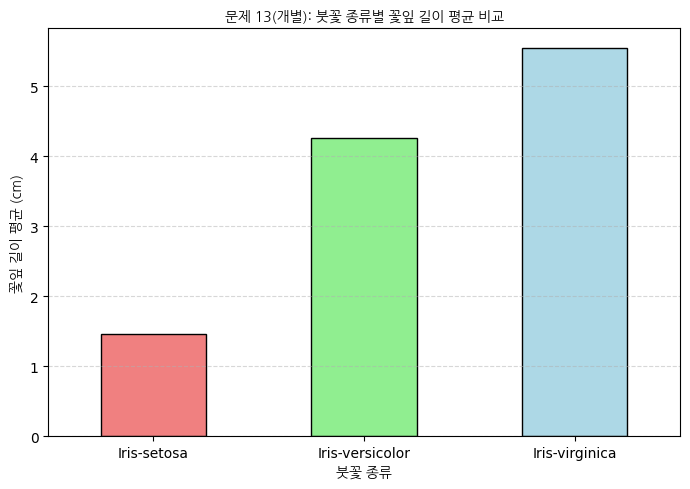

In [ ]:
#13-1 꽃잎 길이의 평균 막대그래프로 그리기

plt.figure(figsize=(7, 5))

summary_table["꽃잎 길이"].plot(
    kind="bar", color=["lightcoral", "lightgreen", "lightblue"], edgecolor="black"
)

plt.title("붓꽃 종류별 꽃잎 길이 평균 비교", fontproperties=font10)
plt.xlabel("붓꽃 종류", fontproperties=font10)
plt.ylabel("꽃잎 길이 평균 (cm)", fontproperties=font10)
plt.xticks(rotation=0)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

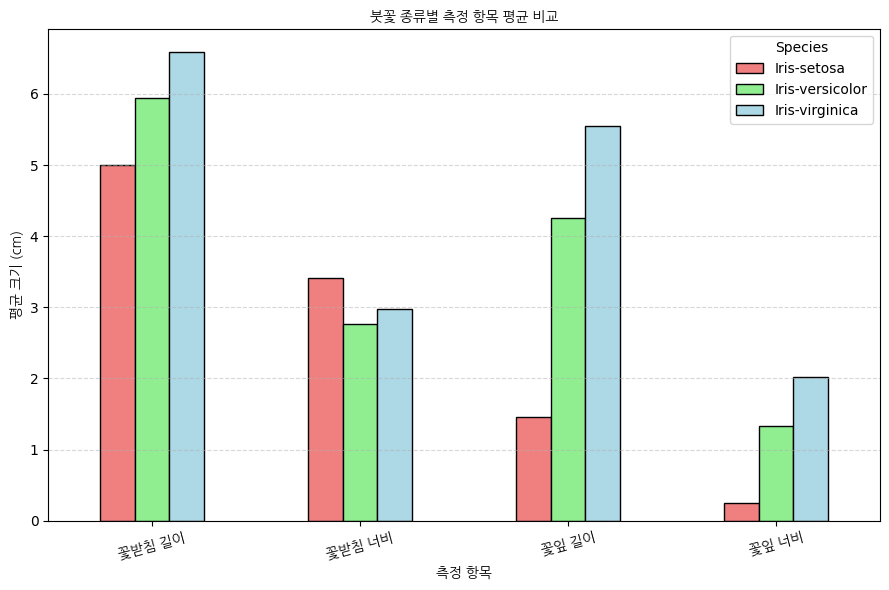

In [ ]:
# 문제 13-2 모든 측정값의 종류별 평균 비교 막대그래프
plt.figure(figsize=(9, 6))

summary_table.T.plot(
    kind="bar",
    color=["lightcoral", "lightgreen", "lightblue"],
    edgecolor="black",
    ax=plt.gca(),
)

plt.title("붓꽃 종류별 측정 항목 평균 비교", fontproperties=font10)
plt.xlabel("측정 항목", fontproperties=font10)
plt.ylabel("평균 크기 (cm)", fontproperties=font10)
plt.gca().set_xticklabels(summary_table.columns, fontproperties=font10, rotation=15)

plt.legend(title="Species")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

=== 문제 14: 종류별 꽃잎 길이 범위 계산 결과 ===
Iris-setosa:
   - 최솟값: 1.0 cm, 최댓값: 1.9 cm
   - 실제 데이터 범위: 0.90 cm
Iris-versicolor:
   - 최솟값: 3.0 cm, 최댓값: 5.1 cm
   - 실제 데이터 범위: 2.10 cm
Iris-virginica:
   - 최솟값: 4.5 cm, 최댓값: 6.9 cm
   - 실제 데이터 범위: 2.40 cm
------------------------------------------------------------
결론: 가장 넓은 범위의 값을 가지는 종류는 'Iris-virginica' 입니다. (범위: 2.40 cm)
------------------------------------------------------------


/tmp/ipykernel_29448/2712042494.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=species_list)


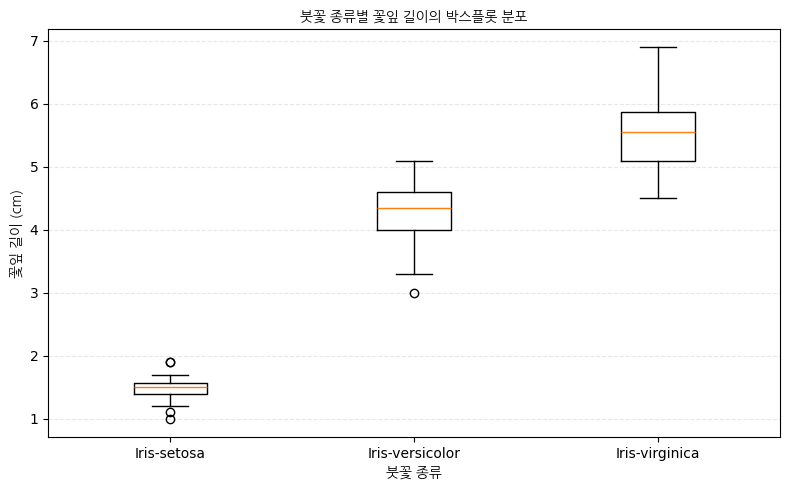

In [ ]:
species_list = df["Species"].unique()
#문제 14-1 종류별 꽃잎 길이 범위 계산 결과
species_list = df["Species"].unique()

print("=== 문제 14: 종류별 꽃잎 길이 범위 계산 결과 ===")

range_dict = {}
for species in species_list:
    # 에러 원인 해결: 'PetalLengthCm' 대신 변환된 이름인 '꽃잎 길이'를 사용합니다!
    petal_lengths = df[df["Species"] == species]["꽃잎 길이"]

    # 최솟값, 최댓값, 범위(최댓값 - 최솟값) 구하기
    min_val = petal_lengths.min()
    max_val = petal_lengths.max()
    val_range = max_val - min_val

    # 딕셔너리에 저장
    range_dict[species] = val_range

    # 텍스트 출력
    print(f"{species}:")
    print(f"   - 최솟값: {min_val} cm, 최댓값: {max_val} cm")
    print(f"   - 실제 데이터 범위: {val_range:.2f} cm")
print("-" * 60)

# 가장 넓은 범위를 가지는 종류 찾기
max_range_species = max(range_dict, key=range_dict.get)
print(
    f"결론: 가장 넓은 범위의 값을 가지는 종류는 '{max_range_species}' 입니다. (범위: {range_dict[max_range_species]:.2f} cm)"
)
print("-" * 60)


# 4. 박스플롯 시각화하기 (독립된 창)
plt.figure(figsize=(8, 5))

# 에러 원인 해결: 여기도 마찬가지로 '꽃잎 길이'로 데이터를 가져옵니다.
data_to_plot = [df[df["Species"] == sp]["꽃잎 길이"] for sp in species_list]

plt.boxplot(data_to_plot, labels=species_list)

plt.title("붓꽃 종류별 꽃잎 길이의 박스플롯 분포", fontproperties=font10)
plt.xlabel("붓꽃 종류", fontproperties=font10)
plt.ylabel("꽃잎 길이 (cm)", fontproperties=font10)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()